In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [5]:
import pandas as pd

df = pd.read_csv("ai_visa_prediction_dataset.csv")
df.head()

,age,nationality,destination_country,visa_type,education_level,years_of_experience,financial_proof_usd,previous_rejections,previous_travel,application_month,visa_status,processing_days
0,46,UK,Canada,Work,Bachelor,7,19952,0,0,4,Approved,74
1,32,Nigeria,Germany,Tourist,Bachelor,10,18701,1,0,3,Rejected,33
2,25,Philippines,Australia,Business,Master,10,12745,1,1,1,Approved,35
3,38,China,UK,Student,Bachelor,11,27335,0,0,5,Approved,77
4,36,Brazil,Germany,Student,Master,13,5689,0,1,3,Approved,62


In [6]:
df.shape


(3000, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  3000 non-null   int64 
 1   nationality          3000 non-null   object
 2   destination_country  3000 non-null   object
 3   visa_type            3000 non-null   object
 4   education_level      3000 non-null   object
 5   years_of_experience  3000 non-null   int64 
 6   financial_proof_usd  3000 non-null   int64 
 7   previous_rejections  3000 non-null   int64 
 8   previous_travel      3000 non-null   int64 
 9   application_month    3000 non-null   int64 
 10  visa_status          3000 non-null   object
 11  processing_days      3000 non-null   int64 
dtypes: int64(7), object(5)
memory usage: 281.4+ KB


In [8]:
df.describe()


,age,years_of_experience,financial_proof_usd,previous_rejections,previous_travel,application_month,processing_days
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,36.350667,6.990333,26408.376333,0.285333,0.589667,6.563333,61.57400
std,10.779352,4.383223,13420.705787,0.547739,0.491976,3.440048,19.67088
min,18.000000,0.000000,3018.000000,0.000000,0.000000,1.000000,20.00000
25%,27.000000,3.000000,15226.250000,0.000000,0.000000,4.000000,48.00000
50%,37.000000,7.000000,26147.000000,0.000000,1.000000,6.000000,64.00000
75%,46.000000,11.000000,37822.250000,0.000000,1.000000,10.000000,76.00000
max,54.000000,14.000000,49998.000000,2.000000,1.000000,12.000000,113.00000


In [9]:
df.describe()

,age,years_of_experience,financial_proof_usd,previous_rejections,previous_travel,application_month,processing_days
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,36.350667,6.990333,26408.376333,0.285333,0.589667,6.563333,61.57400
std,10.779352,4.383223,13420.705787,0.547739,0.491976,3.440048,19.67088
min,18.000000,0.000000,3018.000000,0.000000,0.000000,1.000000,20.00000
25%,27.000000,3.000000,15226.250000,0.000000,0.000000,4.000000,48.00000
50%,37.000000,7.000000,26147.000000,0.000000,1.000000,6.000000,64.00000
75%,46.000000,11.000000,37822.250000,0.000000,1.000000,10.000000,76.00000
max,54.000000,14.000000,49998.000000,2.000000,1.000000,12.000000,113.00000


In [10]:
df.isnull().sum()

,0
age,0
nationality,0
destination_country,0
visa_type,0
education_level,0
years_of_experience,0
financial_proof_usd,0
previous_rejections,0
previous_travel,0
application_month,0


In [11]:
# List of numeric columns in your dataset
numeric_cols = [
    'age',
    'years_of_experience',
    'financial_proof_usd',
    'previous_rejections',
    'previous_travel',
    'application_month',
    'processing_days'
]

# Fill with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [12]:
# List of categorical columns
categorical_cols = [
    'nationality',
    'destination_country',
    'visa_type',
    'education_level',
    'visa_status'
]

# Fill with most frequent value (mode)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.isnull().sum()

,0
age,0
nationality,0
destination_country,0
visa_type,0
education_level,0
years_of_experience,0
financial_proof_usd,0
previous_rejections,0
previous_travel,0
application_month,0


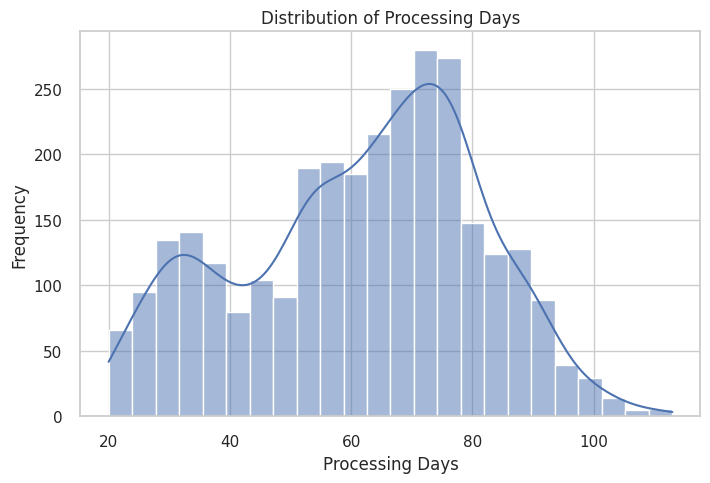

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['processing_days'], kde=True)
plt.title("Distribution of Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Frequency")
plt.show()

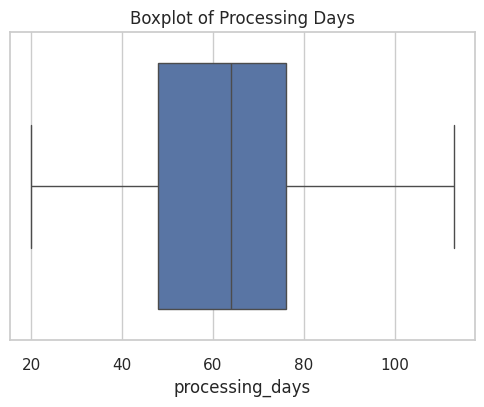

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['processing_days'])
plt.title("Boxplot of Processing Days")
plt.show()

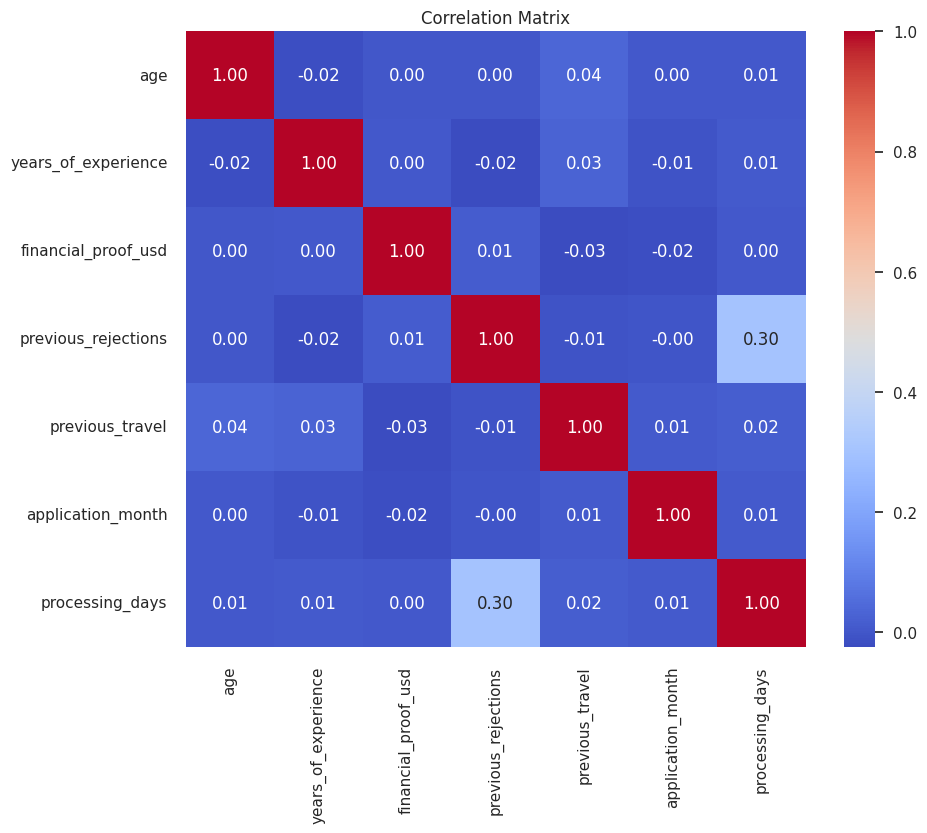

In [16]:
plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [17]:
corr_matrix['processing_days'].sort_values(ascending=False)

,processing_days
processing_days,1.000000
previous_rejections,0.302966
previous_travel,0.015284
years_of_experience,0.008758
application_month,0.006775
age,0.006242
financial_proof_usd,0.004277


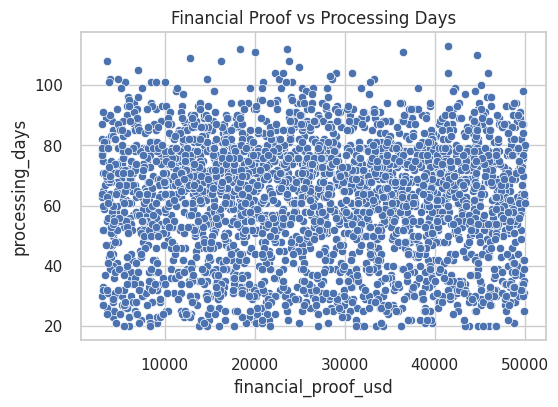

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='financial_proof_usd', y='processing_days', data=df)
plt.title("Financial Proof vs Processing Days")
plt.show()

<Axes: xlabel='previous_rejections', ylabel='processing_days'>

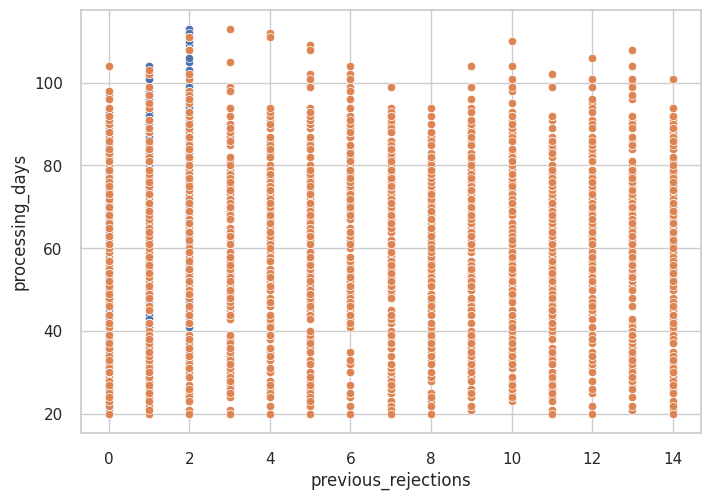

In [19]:
sns.scatterplot(x='previous_rejections', y='processing_days', data=df)
sns.scatterplot(x='years_of_experience', y='processing_days', data=df)

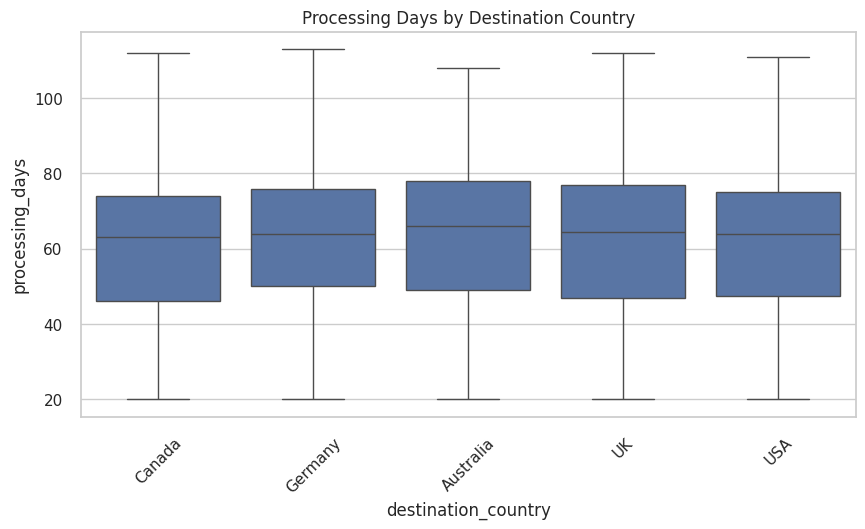

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x='destination_country', y='processing_days', data=df)
plt.xticks(rotation=45)
plt.title("Processing Days by Destination Country")
plt.show()

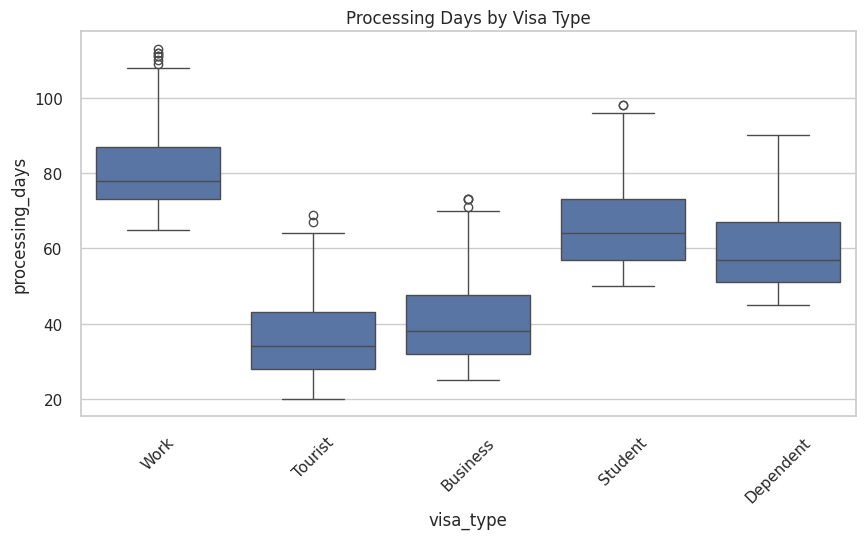

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x='visa_type', y='processing_days', data=df)
plt.xticks(rotation=45)
plt.title("Processing Days by Visa Type")
plt.show()

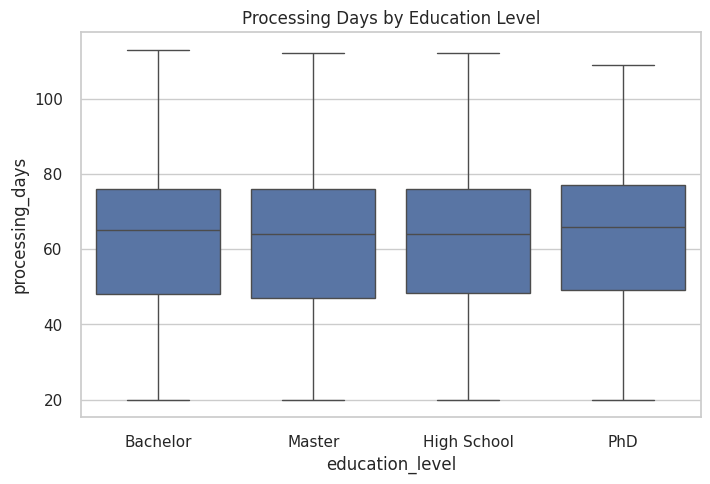

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='education_level', y='processing_days', data=df)
plt.title("Processing Days by Education Level")
plt.show()

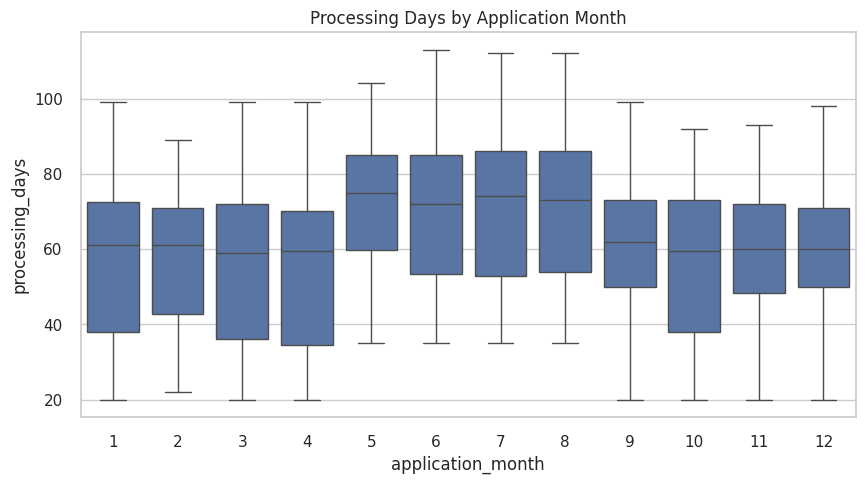

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x='application_month', y='processing_days', data=df)
plt.title("Processing Days by Application Month")
plt.show()

In [24]:
df.groupby('destination_country')['processing_days'].mean().sort_values()

,processing_days
destination_country,
Canada,60.197309
USA,61.455161
UK,61.538596
Germany,62.247906
Australia,62.636998


In [26]:
df.groupby('visa_type')['processing_days'].mean().sort_values()

,processing_days
visa_type,
Tourist,35.218412
Business,39.742671
Dependent,59.365217
Student,65.468026
Work,79.939683
